# Lab №2
## Kinematics and Trajectory Planning

**Robot selected:** UR5 (Universal Robots 5)

In this lab we will:
1. Load the UR5 model and fill in its parameters (from Lab 1)
2. Set an initial configuration and solve forward kinematics
3. Build the manipulator workspace
4. Select a target point and solve inverse kinematics
5. Plan a trajectory using three different methods
6. Plot joint position, velocity, and acceleration profiles

## Steps

### 0. Import the necessary libraries

In [1]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb

### 1. Load the UR5 model

We load the UR5 from the toolbox and print its DH parameters.

In [3]:
robot = rtb.models.DH.UR5()
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



### 2. Fill in the parameters of the robot model

Same parameters as in Lab 1, taken from the UR5 datasheet.

1. Mass of each link (kg)

In [4]:
robot.links[0].m = 3.7
robot.links[1].m = 8.393
robot.links[2].m = 2.275
robot.links[3].m = 1.219
robot.links[4].m = 1.219
robot.links[5].m = 0.1879

2. Center of mass position for each link (m)

In [5]:
robot.links[0].r = [0.0,     -0.02561,  0.00193]
robot.links[1].r = [0.2125,   0.0,      0.11336]
robot.links[2].r = [0.11993,  0.0,      0.0265]
robot.links[3].r = [0.0,      -0.0018,   0.01634]
robot.links[4].r = [0.0,       0.0018,   0.01634]
robot.links[5].r = [0.0,       0.0,     -0.001159]

3. Inertia tensor of each link [Ixx, Iyy, Izz, Ixy, Iyz, Ixz]

In [6]:
robot.links[0].I = [0.010267,  0.010267,  0.00666,  0, 0, 0]
robot.links[1].I = [0.22689,   0.22689,   0.01511,  0, 0, 0]
robot.links[2].I = [0.049443,  0.049443,  0.004095, 0, 0, 0]
robot.links[3].I = [0.001111,  0.001111,  0.000219, 0, 0, 0]
robot.links[4].I = [0.001111,  0.001111,  0.000219, 0, 0, 0]
robot.links[5].I = [0.000171,  0.000171,  0.000034, 0, 0, 0]

4. Motor moment of inertia

In [7]:
robot.links[0].Jm = 0.0001
robot.links[1].Jm = 0.0001
robot.links[2].Jm = 0.0001
robot.links[3].Jm = 0.000033
robot.links[4].Jm = 0.000033
robot.links[5].Jm = 0.000033

5. Viscous friction coefficient of the drive

In [8]:
robot.links[0].B = 0.0015
robot.links[1].B = 0.0015
robot.links[2].B = 0.0015
robot.links[3].B = 0.0007
robot.links[4].B = 0.0007
robot.links[5].B = 0.0007

6. Coulomb friction coefficient [positive, negative]

In [9]:
robot.links[0].Tc = [0.395,  -0.435]
robot.links[1].Tc = [0.395,  -0.435]
robot.links[2].Tc = [0.132,  -0.105]
robot.links[3].Tc = [0.011,  -0.017]
robot.links[4].Tc = [0.011,  -0.017]
robot.links[5].Tc = [0.004,  -0.010]

7. Gear ratio of the reducer

In [10]:
robot.links[0].G = 101.0
robot.links[1].G = 101.0
robot.links[2].G = 101.0
robot.links[3].G = 54.0
robot.links[4].G = 54.0
robot.links[5].G = 54.0

8. Joint angle limits (radians)

In [11]:
robot.links[0].qlim = [-2*pi,  2*pi]
robot.links[1].qlim = [-2*pi,  2*pi]
robot.links[2].qlim = [-pi,    pi]
robot.links[3].qlim = [-2*pi,  2*pi]
robot.links[4].qlim = [-2*pi,  2*pi]
robot.links[5].qlim = [-2*pi,  2*pi]

### 3. Set the initial configuration

We use the home position (all joints at zero) as the starting configuration.

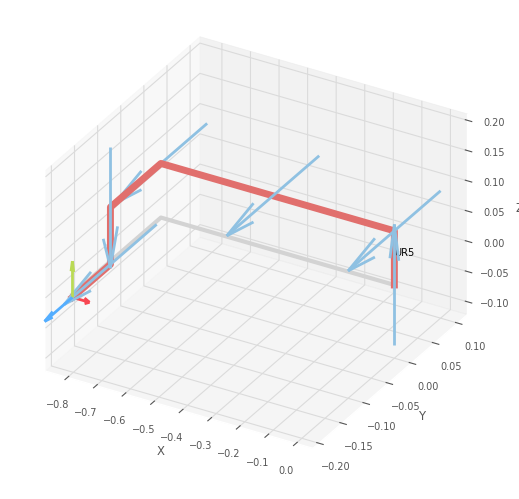

<Figure size 640x480 with 0 Axes>

In [12]:
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

### 4. Forward kinematics

Given the joint angles `q_start`, we compute the end-effector pose using `fkine()`.

In [13]:
T_start = robot.fkine(q_start)
print(T_start)

   1         0         0        -0.8173    
   0         0        -1        -0.1915    
   0         1         0        -0.005191  
   0         0         0         1         



### 5. Build the manipulator workspace

We sweep the first three joints over their full range and compute FK at each point.
Joints 4-6 are fixed at zero — they affect orientation but not reach.

Initialize variables

In [14]:
n = 20  # grid points per joint
i = 0
move = [np.linspace(robot.links[k].qlim[0], robot.links[k].qlim[1], n) for k in range(3)]
pose = np.zeros([3, n**3])

Compute workspace points

In [15]:
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
            Tt = robot.fkine([q1, q2, q3, 0, 0, 0])
            for j in range(3):
                pose[j][i] = Tt.t[j]
            i += 1

Plot the workspace

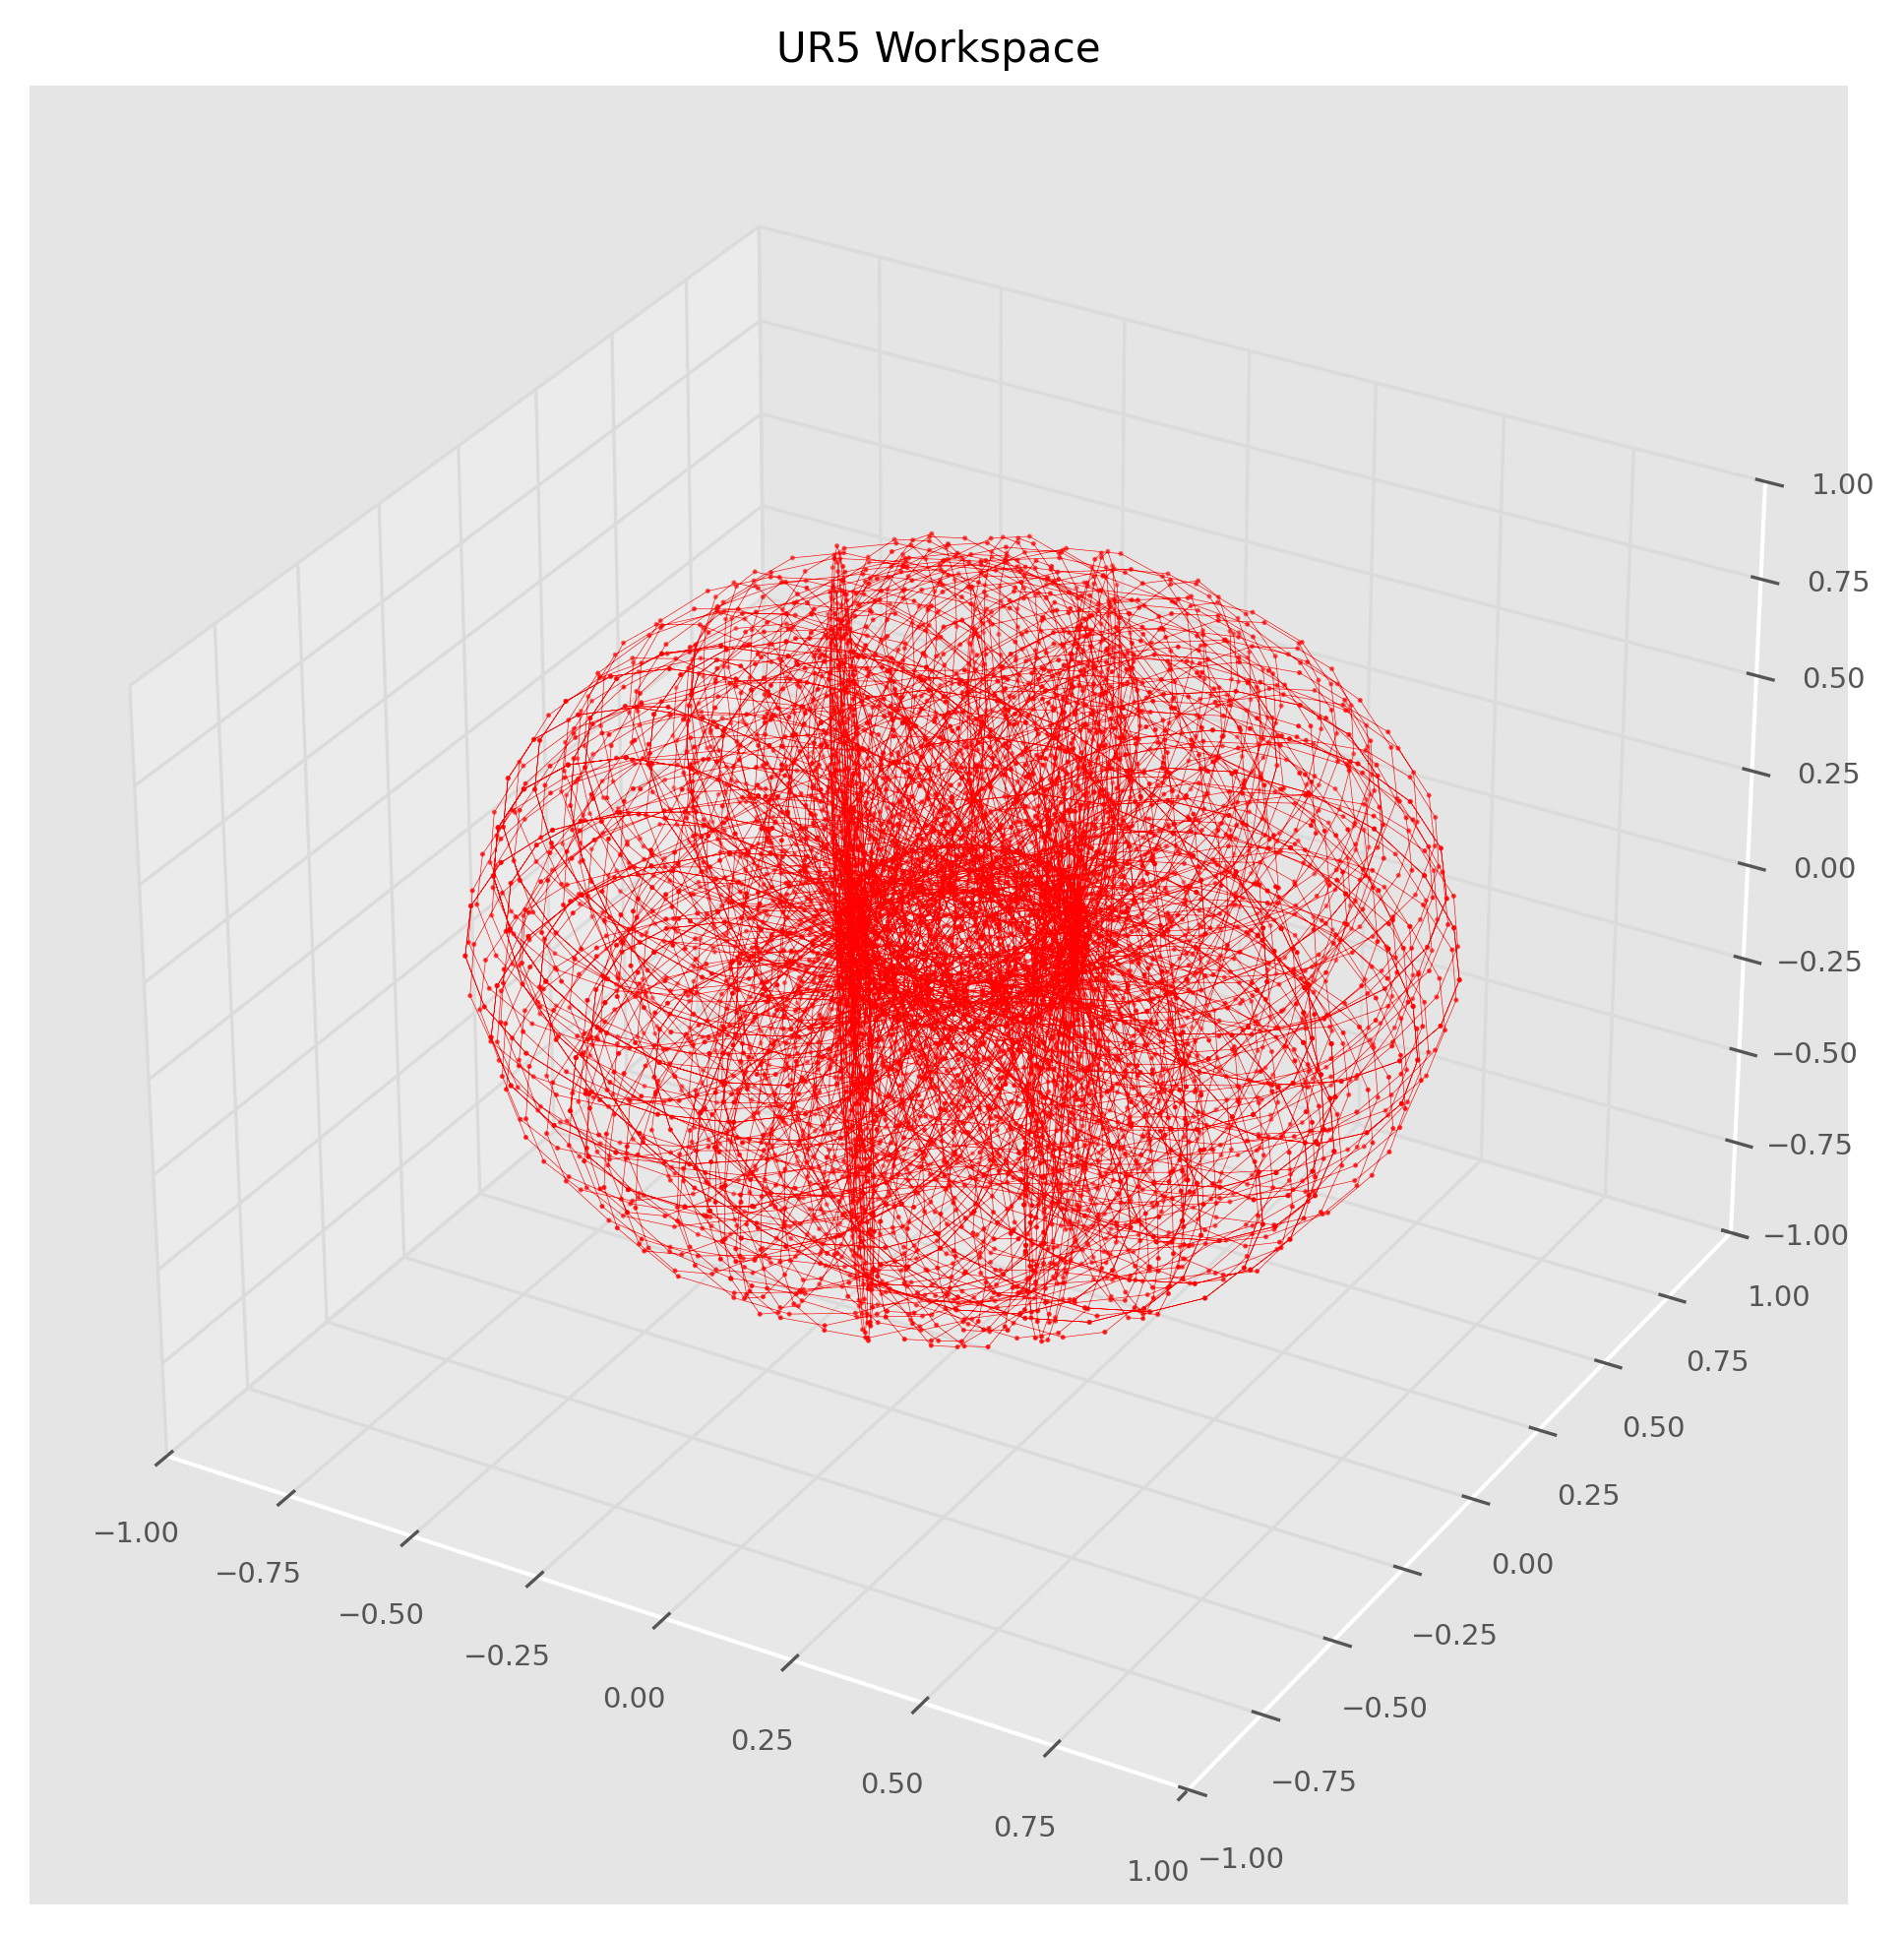

In [16]:
plt.figure(figsize=(8, 8), dpi=300)
ax = plt.axes(projection='3d')
ax.plot3D(pose[0], pose[1], pose[2], color='red', linewidth=0.15)
ax.scatter3D(pose[0], pose[1], pose[2], s=0.5, color='red')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.set_title('UR5 Workspace')
plt.show()

### 6. Select endpoint and solve inverse kinematics

We pick a target configuration, compute its FK to get the end-effector pose, then solve IK numerically with `ikine_LM()`.
This guarantees the target point is inside the workspace.

Target end-effector pose:
   0.09732   0.6098    0.7866    0.01612   
   0.9633   -0.2562    0.07946  -0.1964    
   0.25      0.75     -0.6124    0.7191    
   0         0         0         1         

IK solution (joint angles): [ 0.7854 -1.7926  1.262   2.8868  1.0472 -2.3562]


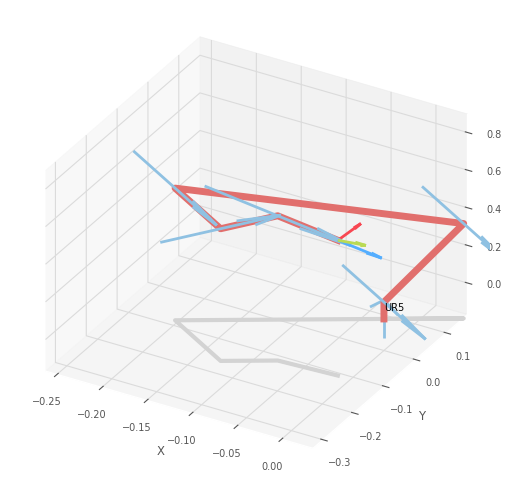

<Figure size 640x480 with 0 Axes>

In [17]:
# Target configuration (same as Lab 1 final pose)
q_end_ref = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4]
T_end = robot.fkine(q_end_ref)
print('Target end-effector pose:')
print(T_end)

# Solve IK
q_end = robot.ikine_LM(T_end).q
print('IK solution (joint angles):', np.round(q_end, 4))

robot.plot(q_end)
plt.show()

### 7. Trajectory planning

We plan the trajectory from "q_start" to "q_end" using three methods and compare them.

**Method 1:** "jtraj" — quintic polynomial in joint space (smooth, zero velocity at endpoints)

In [18]:
N = 100
t_start = 0
t_stop  = 5
t_step  = t_stop / N
time    = np.arange(t_start, t_stop, t_step)

tr_jtraj = rtb.jtraj(q_start, q_end, time)

**Method 2:** "mtraj" with trapezoidal velocity profile (constant velocity phase in the middle)

In [19]:
tr_trap = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

**Method 3:** "mtraj" with quintic polynomial (smooth, similar to jtraj but via mtraj interface)

In [20]:
tr_quin = rtb.mtraj(rtb.quintic, q_start, q_end, time)

### 8. Plot position, velocity and acceleration of all joints

**Joint positions** — all three methods overlaid

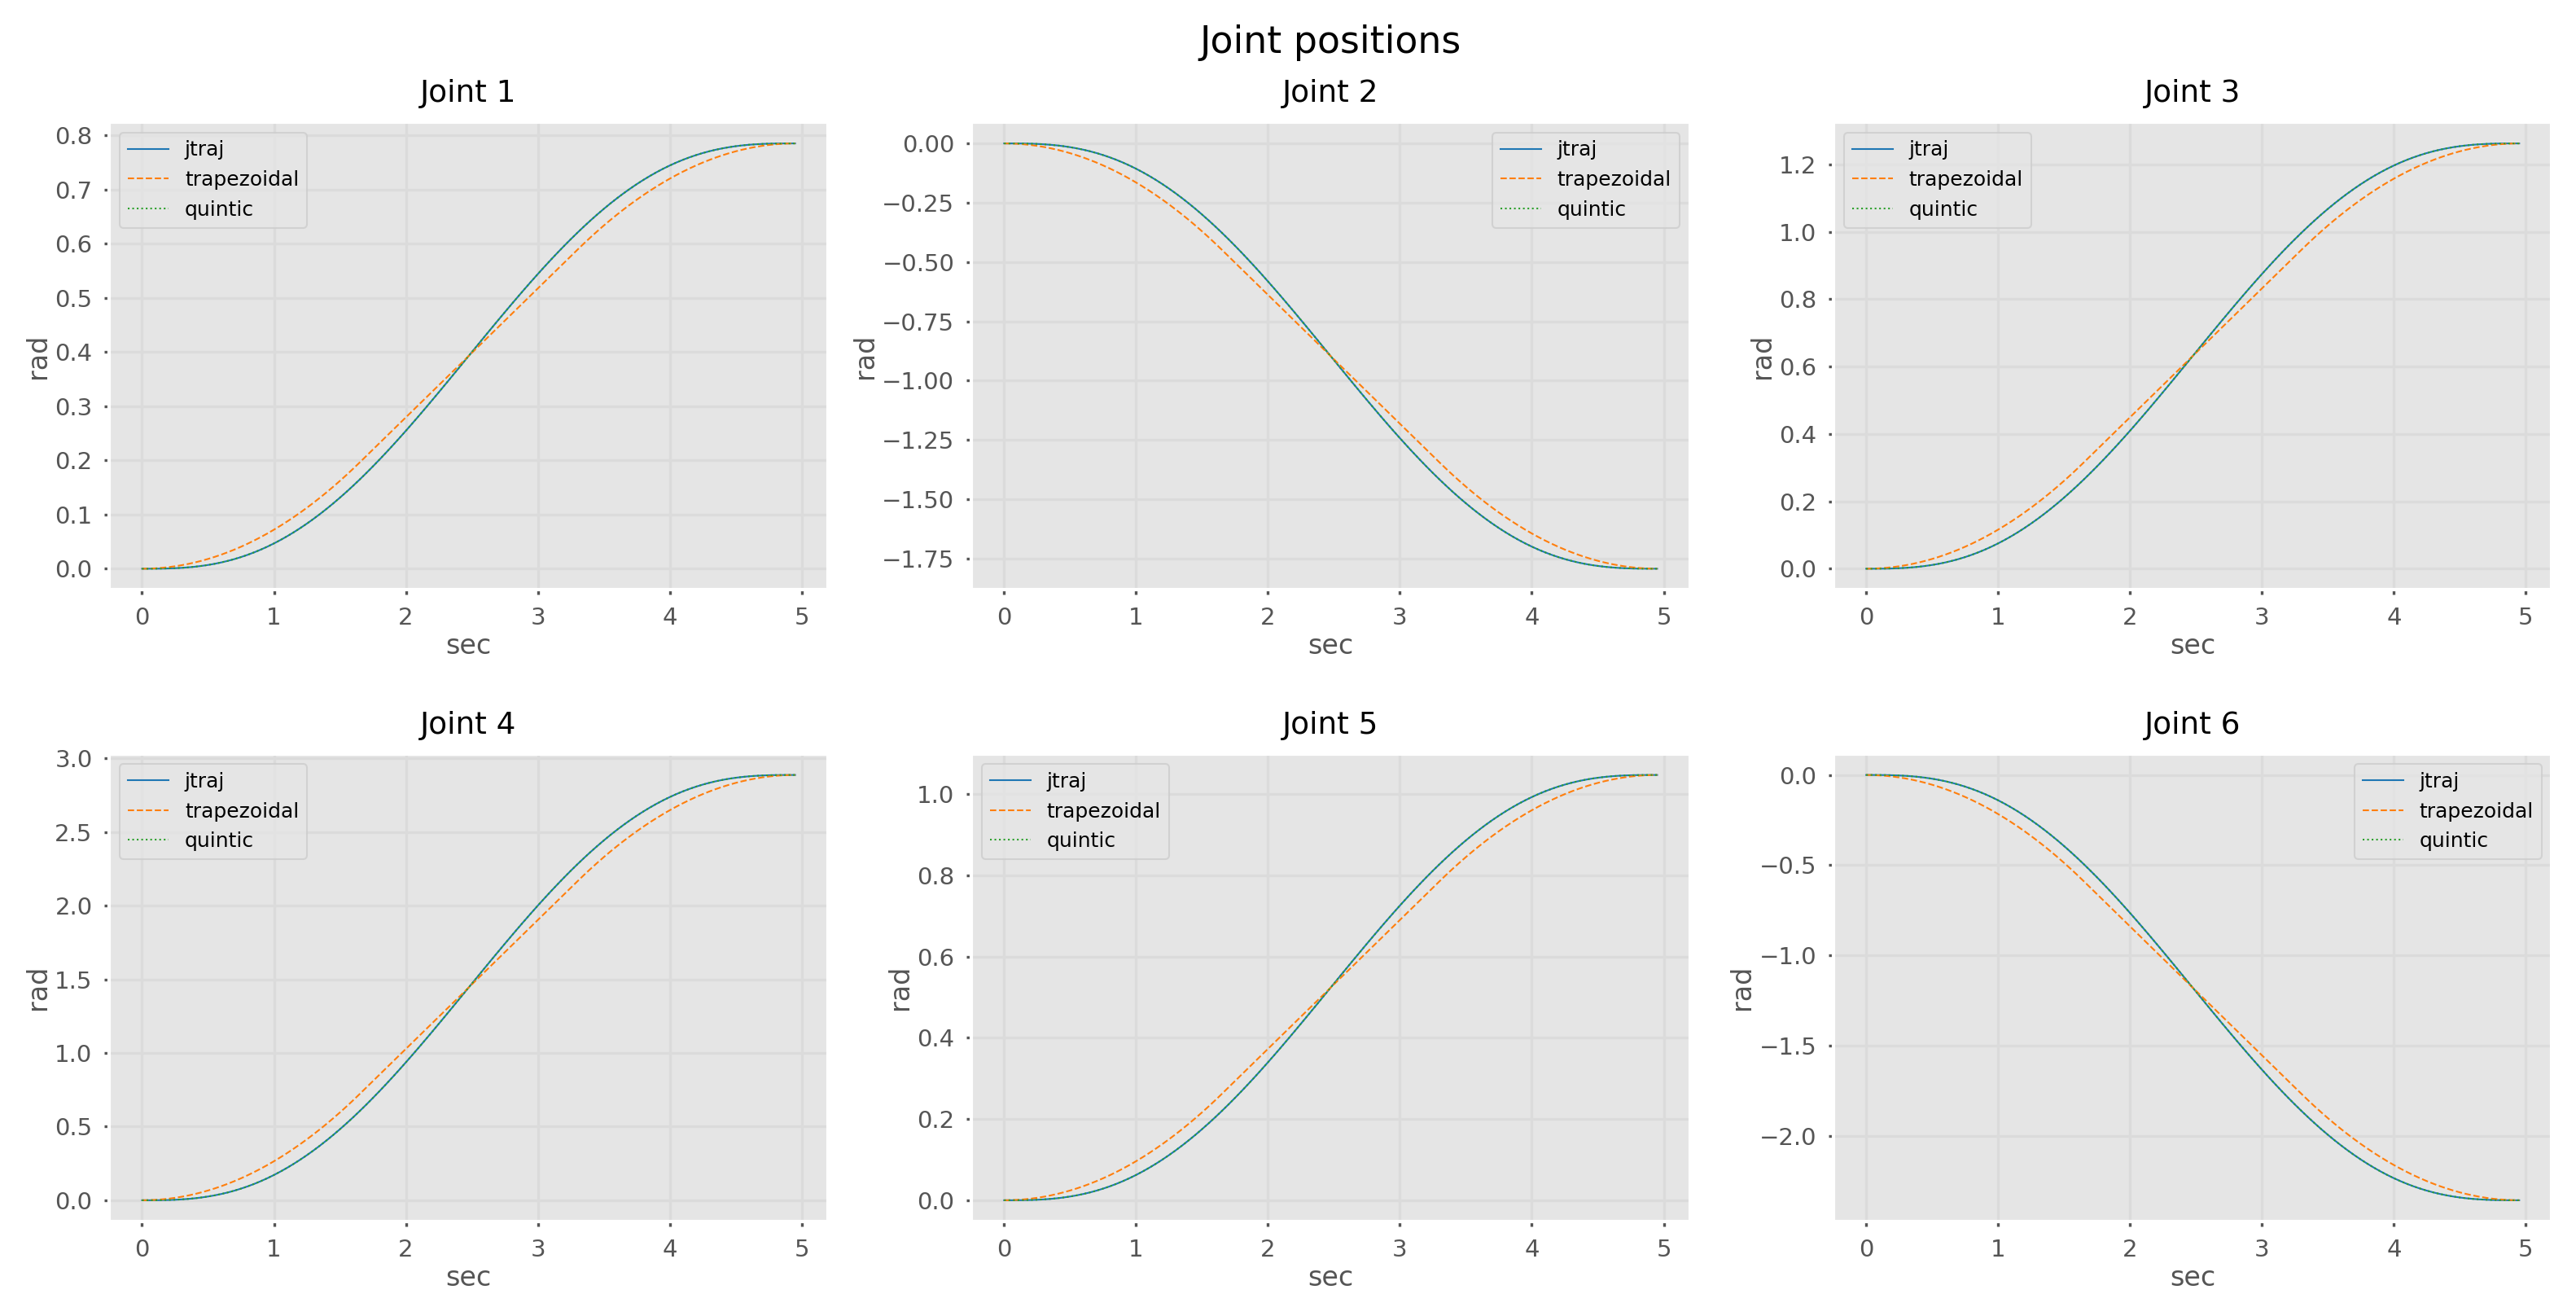

In [21]:
plt.figure(figsize=(10, 5), dpi=300)
plt.suptitle('Joint positions', fontsize=11)
for g in range(1, 7):
    plt.subplot(2, 3, g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.9, wspace=0.2, hspace=0.35)
    traektoriya_jtraj = [tr_jtraj.q[i][g-1] for i in range(len(tr_jtraj.q))]
    traektoriya_trap  = [tr_trap.q[i][g-1]  for i in range(len(tr_trap.q))]
    traektoriya_quin  = [tr_quin.q[i][g-1]  for i in range(len(tr_quin.q))]
    plt.plot(time, traektoriya_jtraj, label='jtraj',        color='tab:blue')
    plt.plot(time, traektoriya_trap,  label='trapezoidal',  color='tab:orange', linestyle='--')
    plt.plot(time, traektoriya_quin,  label='quintic',       color='tab:green',  linestyle=':')
    plt.title(f'Joint {g}', fontsize=9)
    plt.xlabel('sec', fontsize=8)
    plt.ylabel('rad', fontsize=8)
    plt.legend(fontsize=6)
    plt.grid(True)
plt.show()

**Joint velocities**

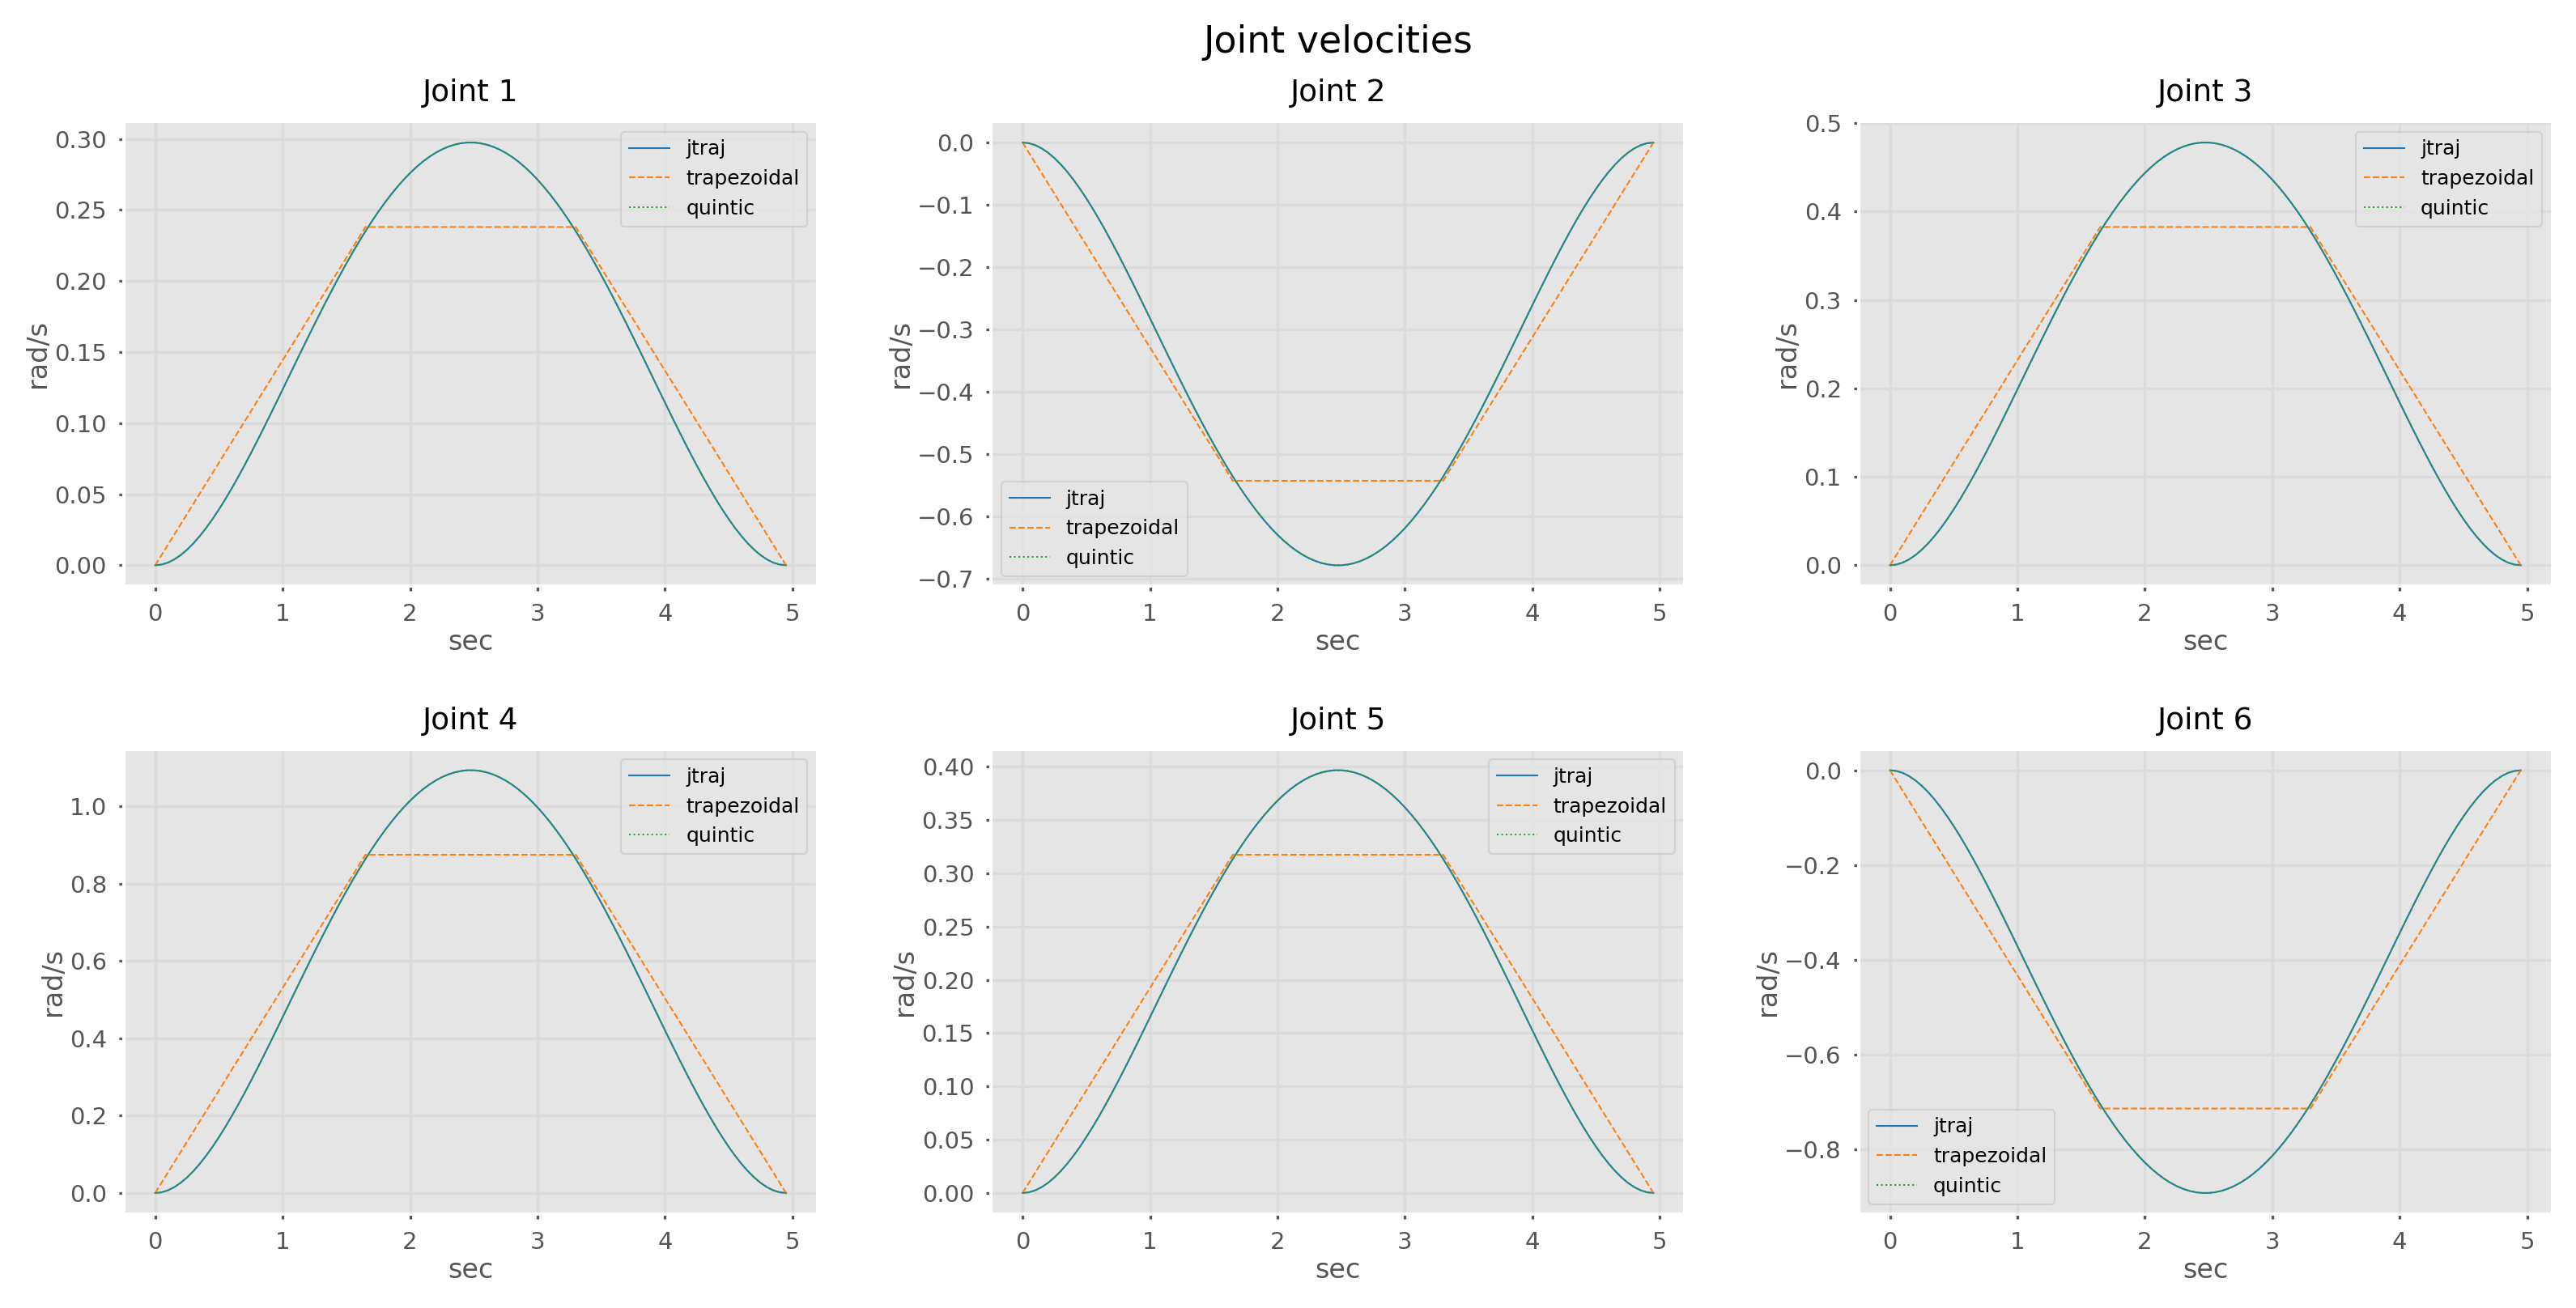

In [22]:
plt.figure(figsize=(10, 5), dpi=300)
plt.suptitle('Joint velocities', fontsize=11)
for g in range(1, 7):
    plt.subplot(2, 3, g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.9, wspace=0.25, hspace=0.35)
    traektoriya_jtraj = [tr_jtraj.qd[i][g-1] for i in range(len(tr_jtraj.qd))]
    traektoriya_trap  = [tr_trap.qd[i][g-1]  for i in range(len(tr_trap.qd))]
    traektoriya_quin  = [tr_quin.qd[i][g-1]  for i in range(len(tr_quin.qd))]
    plt.plot(time, traektoriya_jtraj, label='jtraj',        color='tab:blue')
    plt.plot(time, traektoriya_trap,  label='trapezoidal',  color='tab:orange', linestyle='--')
    plt.plot(time, traektoriya_quin,  label='quintic',       color='tab:green',  linestyle=':')
    plt.title(f'Joint {g}', fontsize=9)
    plt.xlabel('sec', fontsize=8)
    plt.ylabel('rad/s', fontsize=8)
    plt.legend(fontsize=6)
    plt.grid(True)
plt.show()

**Joint accelerations**

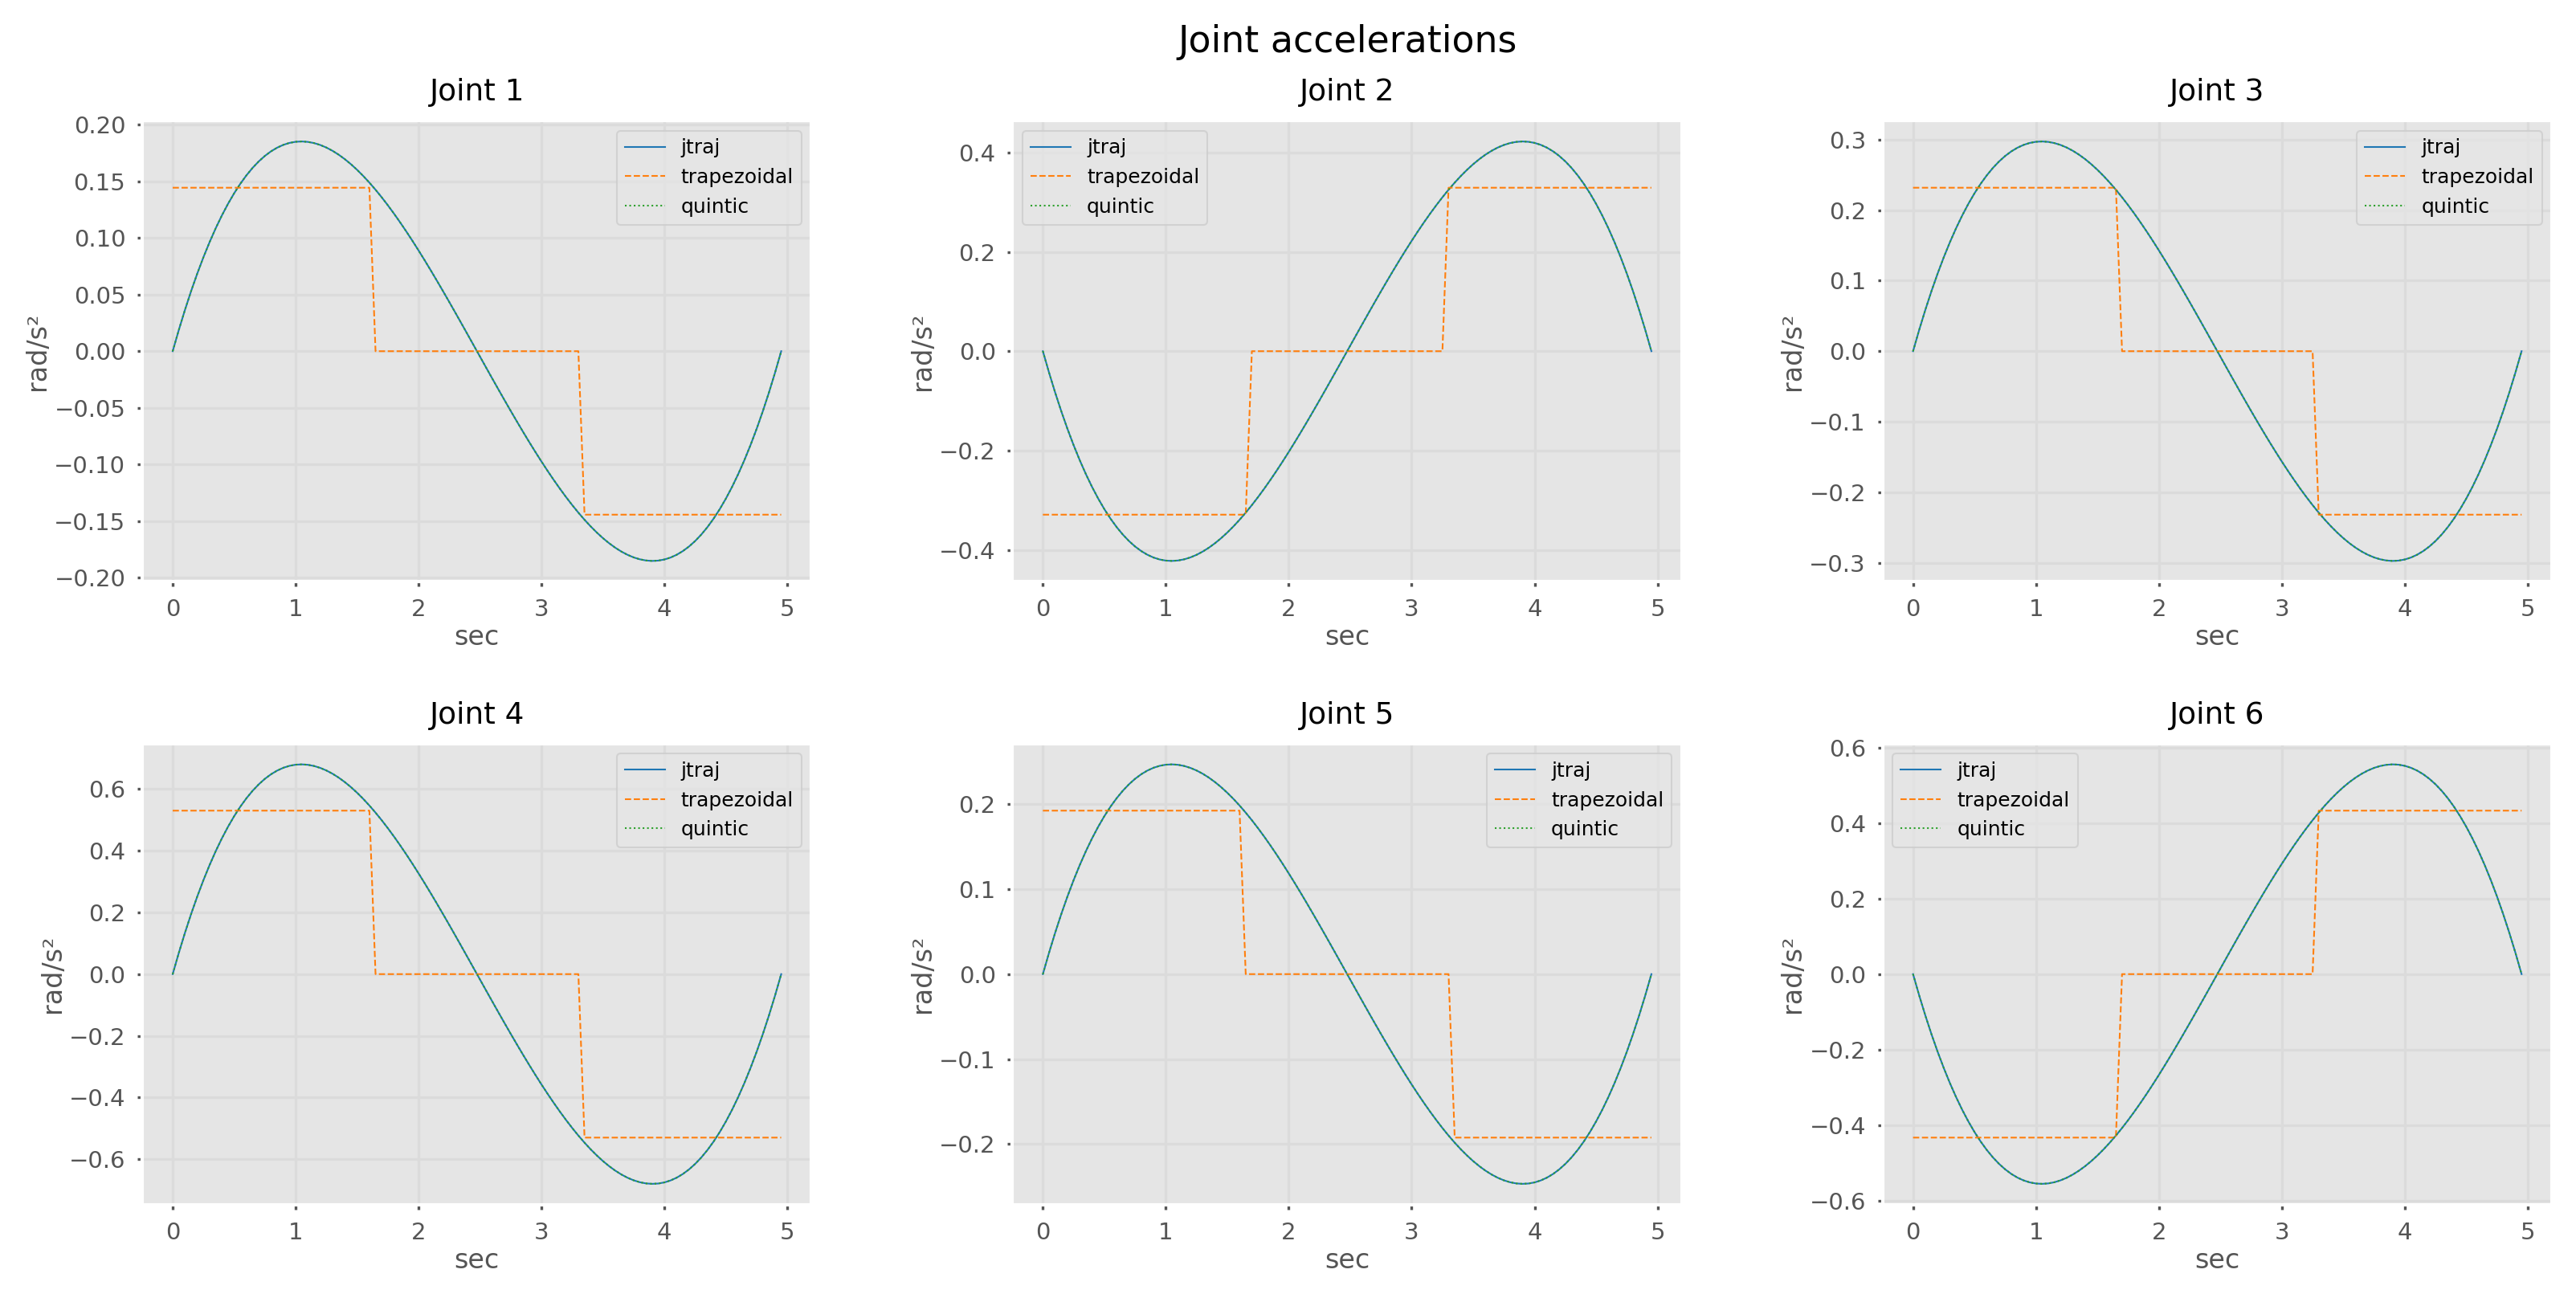

In [23]:
plt.figure(figsize=(10, 5), dpi=300)
plt.suptitle('Joint accelerations', fontsize=11)
for g in range(1, 7):
    plt.subplot(2, 3, g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.9, wspace=0.3, hspace=0.35)
    traektoriya_jtraj = [tr_jtraj.qdd[i][g-1] for i in range(len(tr_jtraj.qdd))]
    traektoriya_trap  = [tr_trap.qdd[i][g-1]  for i in range(len(tr_trap.qdd))]
    traektoriya_quin  = [tr_quin.qdd[i][g-1]  for i in range(len(tr_quin.qdd))]
    plt.plot(time, traektoriya_jtraj, label='jtraj',        color='tab:blue')
    plt.plot(time, traektoriya_trap,  label='trapezoidal',  color='tab:orange', linestyle='--')
    plt.plot(time, traektoriya_quin,  label='quintic',       color='tab:green',  linestyle=':')
    plt.title(f'Joint {g}', fontsize=9)
    plt.xlabel('sec', fontsize=8)
    plt.ylabel('rad/s²', fontsize=8)
    plt.legend(fontsize=6)
    plt.grid(True)
plt.show()

## Conclusions

Forward kinematics gives a unique end-effector pose for any joint configuration, while inverse kinematics is the harder problem: for a given Cartesian target there may be multiple valid joint solutions, and the numerical solver (“ikine_LM”) converges to one depending on its starting guess. The workspace plot shows the full reachable volume of the UR5 when the first three joints are swept — the roughly spherical shell reflects the arm's reach radius. Comparing the three trajectory methods, “jtraj” and “mtraj+quintic” both produce smooth position, velocity, and acceleration profiles that start and end at zero, which avoids mechanical shocks and is preferred for precision tasks. The trapezoidal profile reaches peak velocity faster and holds it constant in the middle, but its acceleration is discontinuous (step changes) — this is more aggressive and can stress the drivetrain. The choice of method is therefore a trade-off between motion smoothness and time efficiency.